# FreshMind  — Predicción de urgencia de consumo de alimentos
- **TFM · Máster Data Science, Big Data y Business
Analytics · UCM 2026**
- **Alumna: Daniela Melendez Dextre**

## 1. Introducción y motivación
En España se desperdician 7,7 millones de toneladas de alimentos al año, con una
pérdida estimada de ~150 €/mes por hogar. Una causa clave: la vida útil real de
un producto cambia drásticamente al abrirlo (unas aceitunas cerradas duran años;
abiertas, unas 2 semanas), pero las apps del mercado solo usan la fecha de la
etiqueta.

**FreshMind** predice la *urgencia real de consumo* (rojo / naranja / verde)
considerando si el producto está abierto o cerrado y dónde se almacena, y
recomienda recetas priorizando lo más urgente.

## Notebook 01 — Fase 1: Datos y EDA
Objetivos: descarga y verificación de datasets (USDA FoodKeeper + Open Food
Facts España), análisis exploratorio, y construcción de la tabla de features
para el Módulo 1 (XGBoost, Fase 2).

##Derechos de uso y licencias de los datos

Antes de trabajar con los datos, se revisó las condiciones de uso de cada fuente,ya que no todas las bases de datos abiertas permiten lo mismo. De hecho, las tres que utilizo tienen niveles de apertura bastante distintos, y eso condiciona lo que se puede hacer con ellas.

**USDA FoodKeeper — licencia CC0 1.0 Universal**

Es la fuente con menos restricciones de las tres. Al estar publicada por el
Servicio de Inocuidad e Inspección de los Alimentos (FSIS) del Departamento de
Agricultura de Estados Unidos, entra dentro de los datos federales de dominio
público, y el catálogo la distribuye bajo CC0 1.0, que renuncia a cualquier
derecho de explotación. En la práctica esto significa que puedo usarla,
transformarla y redistribuirla sin pedir permiso ni citar obligatoriamente,
aunque por rigor académico la cito igualmente. El conjunto se publicó el
10 de noviembre de 2020 y su última actualización es del 22 de enero de 2025,
lo que confirma que sigue siendo un recurso mantenido y no un dataset abandonado.

**Open Food Facts — licencia ODbL v1.0**

Aquí el escenario cambia. Open Food Facts es un proyecto colaborativo y sus
datos se distribuyen bajo la Open Database License, que sí impone obligaciones:
hay que atribuir la fuente y, si se publica una base derivada, debe compartirse
bajo la misma licencia. Es el caso típico de "share-alike": los datos son
libres, pero esa libertad tiene que propagarse. Como este trabajo es académico
y no distribuyo la base modificada como producto, cumplo la licencia
atribuyendo la fuente en esta memoria y en el repositorio del proyecto.

**RecipeNLG — uso académico no comercial**

Es la fuente más restrictiva. El dataset procede de la Universidad Politécnica
de Poznań y su descarga exige aceptar unos términos que limitan el uso a
investigación y fines educativos sin ánimo de lucro, sin garantías sobre el
contenido y trasladando al investigador la responsabilidad sobre el uso de los
textos. Un TFM encaja de lleno en ese supuesto, pero conviene dejarlo por
escrito: el motor de recetas desarrollado aquí no podría comercializarse tal
cual sin renegociar la licencia con la universidad propietaria. Lo menciono
también en el apartado de trabajo futuro, porque es una limitación real de cara
a una hipotética explotación del sistema.

| Fuente | Licencia | ¿Atribución? | ¿Uso comercial? | Acceso |
|---|---|---|---|---|
| USDA FoodKeeper | CC0 1.0 | No obligatoria | Sí | catalog.data.gov/dataset/fsis-foodkeeper-data |
| Open Food Facts | ODbL v1.0 | Sí | Sí, con share-alike | world.openfoodfacts.org/data |
| RecipeNLG | Términos PUT (no comercial) | Sí | No | kaggle.com/datasets/paultimothymooney/recipenlg |

In [1]:
# 1. Instalar e importar librerías
!pip install xlrd duckdb -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import duckdb
print("Librerías listas. DuckDB:", duckdb.__version__)

Librerías listas. DuckDB: 1.3.2


In [2]:
#2.Conectar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Sin subcarpeta 'datos': el archivo está directamente en TFM_FreshMind
RUTA = '/content/drive/MyDrive/TFM_FreshMind/'
print("Drive montado. Carpeta de datos:", RUTA)

Mounted at /content/drive
Drive montado. Carpeta de datos: /content/drive/MyDrive/TFM_FreshMind/


In [3]:
#3.Cargar USDA FoodKeeper desde Drive
hojas = pd.read_excel(RUTA + 'FoodKeeper-Data.xls', sheet_name=None)

for nombre, tabla in hojas.items():
    print(f"{nombre:20s} -> {tabla.shape[0]} filas, {tabla.shape[1]} columnas")

productos = hojas["Product"]
categorias = hojas["Category"]

Version              -> 21 filas, 6 columnas
Category             -> 25 filas, 3 columnas
Product              -> 661 filas, 38 columnas
CookingTips          -> 93 filas, 6 columnas
CookingMethods       -> 89 filas, 11 columnas
Data Dictionary      -> 62 filas, 3 columnas


In [4]:
# 4. Muestra de productos españoles de Open Food Facts

URL_OFF = "https://huggingface.co/datasets/openfoodfacts/product-database/resolve/main/food.parquet"

duckdb.sql("SET enable_object_cache=true;")

off_espana = duckdb.sql(f"""
    SELECT code, product_name, brands, categories_tags, countries_tags
    FROM '{URL_OFF}'
    WHERE list_contains(countries_tags, 'en:spain')
    LIMIT 5000
""").df()

print("Filas obtenidas:", off_espana.shape[0])
off_espana.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Filas obtenidas: 5000


,code,product_name,brands,categories_tags,countries_tags
0,0009800300037,"[{'lang': 'main', 'text': 'gum cool watermelon...",Tic Tac,"[en:snacks, en:sweet-snacks, en:confectionerie...","[en:france, en:spain, en:united-states]"
1,8422947520014,"[{'lang': 'main', 'text': 'Seitán en lonchas'}...",Soria Natural,"[en:plant-based-foods-and-beverages, en:plant-...",[en:spain]
2,00013029,"[{'lang': 'main', 'text': 'Cheddar'}, {'lang':...",McDonald's,"[en:dairies, en:fermented-foods, en:fermented-...","[en:denmark, en:france, en:norway, en:poland, ..."
3,0011210115644,"[{'lang': 'main', 'text': 'Tabasco Rojo'}, {'l...","McIlhenny Company, Tabasco","[en:condiments, en:sauces, en:hot-sauces, en:g...","[en:belgium, en:spain]"
4,0011848425733,"[{'lang': 'main', 'text': 'red habanero pepper...",La Anita,"[en:condiments, en:sauces, en:groceries]","[en:france, en:spain]"


In [5]:
# 5. Guardar la muestra española en Drive
off_espana.to_parquet(RUTA + 'off_espana.parquet')

print("Guardado en:", RUTA + 'off_espana.parquet')
print("En sesiones futuras basta con:")
print("   off_espana = pd.read_parquet(RUTA + 'off_espana.parquet')")

Guardado en: /content/drive/MyDrive/TFM_FreshMind/off_espana.parquet
En sesiones futuras basta con:
   off_espana = pd.read_parquet(RUTA + 'off_espana.parquet')


In [6]:
# 6. Cruzar productos con sus categorías

# Etiqueta legible uniendo categoría y subcategoría
categorias['Categoria'] = (categorias['Category_Name'] +
    categorias['Subcategory_Name'].fillna('').apply(lambda s: ' - ' + s if s else ''))

# Unimos: cada producto recibe el nombre de su categoría
fk = productos.merge(categorias[['ID', 'Categoria']],
                     left_on='Category_ID', right_on='ID',
                     how='left', suffixes=('', '_cat'))

print("Filas tras el cruce:", fk.shape[0])
print("Productos sin categoría asignada:", fk['Categoria'].isna().sum())

Filas tras el cruce: 661
Productos sin categoría asignada: 0


In [7]:
# 7. ¿Cuántos productos hay por categoría?
conteo = fk['Categoria'].value_counts()
print("Total de categorías:", len(conteo))
print()
print(conteo.to_string())

Total de categorías: 25

Categoria
Shelf Stable Foods                   104
Produce - Fresh Vegetables            68
Baked Goods - Baking and Cooking      52
Condiments, Sauces & Canned Goods     52
Meat - Fresh                          49
Dairy Products & Eggs                 46
Deli & Prepared Foods                 36
Beverages                             34
Produce - Fresh Fruits                33
Meat - Smoked or Processed            31
Grains, Beans & Pasta                 30
Food Purchased Frozen                 25
Baked Goods - Bakery                  23
Poultry - Fresh                       16
Seafood - Shellfish                   13
Baked Goods - Refrigerated Dough       7
Baby Food                              7
Seafood - Fresh                        6
Poultry - Cooked or Processed          6
Meat - Shelf Stable Foods              6
Seafood - Smoked                       5
Vegetarian Proteins                    5
Poultry - Stuffed or Assembled         3
Meat - Stuffed or Asse

In [8]:
# 8. ¿Qué unidades de tiempo aparecen en el dataset?
# Antes de convertir a días, verificamos qué valores existen realmente
cols_metric = [c for c in fk.columns if 'Metric' in c]
print("Columnas de unidad encontradas:", len(cols_metric))
print()

# Juntamos todos los valores únicos de todas esas columnas
unidades = pd.unique(fk[cols_metric].values.ravel())
print("Unidades distintas presentes:")
for u in unidades:
    print("   ", repr(u))

Columnas de unidad encontradas: 9

Unidades distintas presentes:
    nan
    'Months'
    'Weeks'
    'Not Recommended'
    'Days'
    'Package use-by date'
    'Years'
    'Hours'
    'Indefinitely'
    'Year'
    'When Ripe'


In [9]:
# 9. Convertir todas las duraciones a días
# Cada duración viene como par (número, unidad). Unificamos todo a días.
# Decisiones tomadas (justificadas en la memoria):
# 'Indefinitely' -> 3650 días (10 años): productos no perecederos
# 'Not Recommended', 'When Ripe', 'Package use-by date' -> NaN
import numpy as np

FACTORES = {'Hours': 1/24, 'Days': 1, 'Weeks': 7,
            'Months': 30, 'Years': 365, 'Year': 365,
            'Indefinitely': 3650}

def convertir_a_dias(valor, unidad):
    """Convierte (valor, unidad) a número de días. NaN si no es cuantificable."""
    if unidad == 'Indefinitely':
        return 3650                      # no perecedero
    if pd.isna(valor) or unidad not in FACTORES:
        return np.nan                    # sin dato o unidad no numérica
    return valor * FACTORES[unidad]

# Probamos la función antes de aplicarla (buena práctica)
print(convertir_a_dias(2, 'Weeks'))          # esperado: 14
print(convertir_a_dias(3, 'Months'))         # esperado: 90
print(convertir_a_dias(1, 'Indefinitely'))   # esperado: 3650
print(convertir_a_dias(5, 'When Ripe'))      # esperado: nan

14
90
3650
nan


In [10]:
# 10. Aplicar la conversión a las columnas de vida útil
# Usamos los valores Min (extremo conservador): en seguridad alimentaria
# Pares (columna_valor, columna_unidad) -> nombre nuevo en días
pares = {
    'Pantry_Min':                    ('Pantry_Metric',                    'dias_despensa_cerrado'),
    'Refrigerate_Min':               ('Refrigerate_Metric',               'dias_nevera_cerrado'),
    'Freeze_Min':                    ('Freeze_Metric',                    'dias_congelador'),
    'Pantry_After_Opening_Min':      ('Pantry_After_Opening_Metric',      'dias_despensa_abierto'),
    'Refrigerate_After_Opening_Min': ('Refrigerate_After_Opening_Metric', 'dias_nevera_abierto'),
}

for col_valor, (col_unidad, nombre_nuevo) in pares.items():
    fk[nombre_nuevo] = fk.apply(
        lambda fila: convertir_a_dias(fila[col_valor], fila[col_unidad]), axis=1)

# Verificamos cuántos productos tienen dato en cada nueva columna
nuevas = [n for _, (_, n) in pares.items()]
print("Productos CON dato en cada columna (de 661):")
print(fk[nuevas].notna().sum().to_string())

Productos CON dato en cada columna (de 661):
dias_despensa_cerrado    104
dias_nevera_cerrado      130
dias_congelador          146
dias_despensa_abierto     76
dias_nevera_abierto      145


In [11]:
# 11. Reestructurar a formato largo (una fila por escenario)
# En vez de un producto con 5 columnas de duración, generamos una fila por
# cada escenario con dato: producto + abierto/cerrado + lugar + días.

escenarios = [
    ('dias_despensa_cerrado', 'cerrado', 'despensa'),
    ('dias_nevera_cerrado',   'cerrado', 'nevera'),
    ('dias_congelador',       'cerrado', 'congelador'),
    ('dias_despensa_abierto', 'abierto', 'despensa'),
    ('dias_nevera_abierto',   'abierto', 'nevera'),
]

trozos = []
for columna, estado, lugar in escenarios:
    t = fk[['Name', 'Categoria', columna]].dropna(subset=[columna]).copy()
    t = t.rename(columns={columna: 'dias_vida_util'})
    t['estado'] = estado
    t['lugar'] = lugar
    trozos.append(t)

datos = pd.concat(trozos, ignore_index=True)

print("Filas totales del dataset reestructurado:", datos.shape[0])
print()
print(datos.groupby(['estado', 'lugar']).size().to_string())
datos.head()

Filas totales del dataset reestructurado: 601

estado   lugar     
abierto  despensa       76
         nevera        145
cerrado  congelador    146
         despensa      104
         nevera        130


,Name,Categoria,dias_vida_util,estado,lugar
0,Jerky,Meat - Shelf Stable Foods,30.000000,cerrado,despensa
1,Fruit pies,Baked Goods - Bakery,1.000000,cerrado,despensa
2,Pies,Baked Goods - Bakery,0.083333,cerrado,despensa
3,Pies,Baked Goods - Bakery,0.083333,cerrado,despensa
4,Pies,Baked Goods - Bakery,0.083333,cerrado,despensa


In [12]:
# 11b. Limpieza del dataset reestructurado
# 1) Añadimos Name_subtitle para distinguir subtipos con el mismo nombre
# 2) Eliminamos duraciones menores a 1 día (vienen en horas: no aplican
#    a gestión doméstica de despensa)
# 3) Eliminamos duplicados exactos
trozos = []
for columna, estado, lugar in escenarios:
    t = fk[['Name', 'Name_subtitle', 'Categoria', columna]].dropna(subset=[columna]).copy()
    t = t.rename(columns={columna: 'dias_vida_util'})
    t['estado'] = estado
    t['lugar'] = lugar
    trozos.append(t)

datos = pd.concat(trozos, ignore_index=True)

# Nombre completo: producto + matiz (ej. "Pies - pumpkin")
datos['producto'] = (datos['Name'] +
    datos['Name_subtitle'].fillna('').apply(lambda s: ' - ' + s if s else ''))

antes = datos.shape[0]
datos = datos[datos['dias_vida_util'] >= 1]           # fuera duraciones en horas
datos = datos.drop_duplicates(subset=['producto', 'estado', 'lugar'])

print(f"Filas antes: {antes} -> después de limpiar: {datos.shape[0]}")
print()
print(datos.groupby(['estado', 'lugar']).size().to_string())

Filas antes: 601 -> después de limpiar: 595

estado   lugar     
abierto  despensa       75
         nevera        144
cerrado  congelador    146
         despensa      100
         nevera        130


In [13]:
# 12. Ampliar con los escenarios DOP y tras descongelar
# DOP = Date Of Purchase: vida útil contada desde la compra, no desde fabricación. Es el escenario más realista

pares_extra = {
'DOP_Pantry_Min':                 ('DOP_Pantry_Metric',                 'dias_dop_despensa'),
'DOP_Refrigerate_Min':            ('DOP_Refrigerate_Metric',            'dias_dop_nevera'),
'DOP_Freeze_Min':                 ('DOP_Freeze_Metric',                 'dias_dop_congelador'),
'Refrigerate_After_Thawing_Min':  ('Refrigerate_After_Thawing_Metric',  'dias_nevera_descongelado'),
}

for col_valor, (col_unidad, nombre_nuevo) in pares_extra.items():
    if col_valor in fk.columns and col_unidad in fk.columns:
        fk[nombre_nuevo] = fk.apply(
            lambda fila: convertir_a_dias(fila[col_valor], fila[col_unidad]), axis=1)

nuevas_extra = [n for _, (_, n) in pares_extra.items() if n in fk.columns]
print("Cobertura de los nuevos escenarios (de 661):")
print(fk[nuevas_extra].notna().sum().to_string())

Cobertura de los nuevos escenarios (de 661):
dias_dop_despensa           197
dias_dop_nevera             235
dias_dop_congelador         196
dias_nevera_descongelado      3


In [14]:
# 13. Dataset final con todos los escenarios
# Añadimos los escenarios DOP y descongelado a los originales.
escenarios_todos = [
    ('dias_despensa_cerrado',    'cerrado',      'despensa',   'fabricacion'),
    ('dias_nevera_cerrado',      'cerrado',      'nevera',     'fabricacion'),
    ('dias_congelador',          'cerrado',      'congelador', 'fabricacion'),
    ('dias_despensa_abierto',    'abierto',      'despensa',   'fabricacion'),
    ('dias_nevera_abierto',      'abierto',      'nevera',     'fabricacion'),
    ('dias_dop_despensa',        'cerrado',      'despensa',   'compra'),
    ('dias_dop_nevera',          'cerrado',      'nevera',     'compra'),
    ('dias_dop_congelador',      'cerrado',      'congelador', 'compra'),
    ('dias_nevera_descongelado', 'descongelado', 'nevera',     'compra'),
]

trozos = []
for columna, estado, lugar, referencia in escenarios_todos:
    if columna not in fk.columns:
        continue
    t = fk[['Name', 'Name_subtitle', 'Categoria', columna]].dropna(subset=[columna]).copy()
    t = t.rename(columns={columna: 'dias_vida_util'})
    t['estado'] = estado
    t['lugar'] = lugar
    t['referencia'] = referencia   # desde fabricación o desde compra
    trozos.append(t)

datos = pd.concat(trozos, ignore_index=True)
datos['producto'] = (datos['Name'] +
    datos['Name_subtitle'].fillna('').apply(lambda s: ' - ' + s if s else ''))

datos = datos[datos['dias_vida_util'] >= 1]
datos = datos.drop_duplicates(subset=['producto', 'estado', 'lugar', 'referencia'])

print("FILAS DEL DATASET FINAL:", datos.shape[0])
print()
print(datos.groupby(['referencia', 'estado', 'lugar']).size().to_string())

FILAS DEL DATASET FINAL: 1226

referencia   estado        lugar     
compra       cerrado       congelador    196
                           despensa      197
                           nevera        235
             descongelado  nevera          3
fabricacion  abierto       despensa       75
                           nevera        144
             cerrado       congelador    146
                           despensa      100
                           nevera        130


In [15]:
# 14. Guardar el dataset analítico en Drive
datos.to_parquet(RUTA + 'foodkeeper_escenarios.parquet')
print("Guardado:", datos.shape[0], "filas en", RUTA + 'foodkeeper_escenarios.parquet')

Guardado: 1226 filas en /content/drive/MyDrive/TFM_FreshMind/foodkeeper_escenarios.parquet


In [16]:
# 15. Crear la variable objetivo: urgencia
# Umbrales: rojo <= 2 días | naranja 3-7 días | verde > 7 días
# El modelo predecirá esta clase sin ver los días, solo a partir de
# categoría, estado, lugar y referencia
def clasificar_urgencia(dias):
    if dias <= 2:
        return 'rojo'
    elif dias <= 7:
        return 'naranja'
    else:
        return 'verde'

datos['urgencia'] = datos['dias_vida_util'].apply(clasificar_urgencia)

print("Distribución de la variable objetivo:")
print(datos['urgencia'].value_counts().to_string())
print()
print("En porcentaje:")
print((datos['urgencia'].value_counts(normalize=True) * 100).round(1).to_string())

Distribución de la variable objetivo:
urgencia
verde      848
naranja    276
rojo       102

En porcentaje:
urgencia
verde      69.2
naranja    22.5
rojo        8.3


In [17]:
# 16b.comparación emparejada por producto
# Comparamos el mismo producto cerrado vs abierto
comp = datos[(datos['lugar'] == 'nevera') &
             (datos['referencia'] == 'fabricacion')]

tabla = comp.pivot_table(index='producto', columns='estado',
                         values='dias_vida_util', aggfunc='min')

# Nos quedamos con los productos que tienen ambos valores
tabla = tabla.dropna(subset=['abierto', 'cerrado'])

print("Productos con dato de abierto Y cerrado:", len(tabla))
print()
print("Mediana cerrado:", tabla['cerrado'].median(), "días")
print("Mediana abierto:", tabla['abierto'].median(), "días")
print()
print(tabla.head(10).to_string())

Productos con dato de abierto Y cerrado: 6

Mediana cerrado: 7.0 días
Mediana abierto: 3.0 días

estado                                                 abierto  cerrado
producto                                                               
Bagged greens - leaf, spinach, lettuce, etc.               2.0      3.0
Beef broth/stock/consommé  - commercially produced         3.0      7.0
Chicken broth/stock/consommé  - commercially produced      3.0      7.0
Milk  - ultra-pasteurized                                  7.0     30.0
Vegetable stock/broth  - commercially produced             3.0      7.0
Vegetables                                                 2.0      3.0


In [18]:
# 16c. Comparación emparejada (todas las referencias)
# Ampliamos: cualquier producto con dato de abierto Y cerrado,
# en nevera o despensa. Tomamos el mínimo por producto y estado.
comp = datos[datos['lugar'].isin(['nevera', 'despensa'])]

tabla = comp.pivot_table(index='producto', columns='estado',
                         values='dias_vida_util', aggfunc='min')
tabla = tabla.dropna(subset=['abierto', 'cerrado'])

# Cuántas veces se reduce la vida útil al abrir
tabla['reduccion_x'] = (tabla['cerrado'] / tabla['abierto']).round(1)

print("Productos comparables:", len(tabla))
print("Mediana cerrado:", tabla['cerrado'].median(), "| abierto:", tabla['abierto'].median())
print("Reducción mediana:", tabla['reduccion_x'].median(), "veces")
print()
print(tabla.sort_values('reduccion_x', ascending=False).head(15).to_string())

Productos comparables: 167
Mediana cerrado: 365.0 | abierto: 30.0
Reducción mediana: 4.1 veces

estado                                                                                                                           abierto  cerrado  descongelado  reduccion_x
producto                                                                                                                                                                    
Red wine                                                                                                                             1.0   1095.0           NaN       1095.0
Gravy - jars and cans                                                                                                                1.0    730.0           NaN        730.0
Anchovies - canned                                                                                                                   3.0   1825.0           NaN        608.3
Canned chicken                         

In [19]:
# 17 Verificar cómo se llama la columna de ID en fk antes de cruzar
print([c for c in fk.columns if 'ID' in c or 'Id' in c])

['ID', 'Category_ID', 'ID_cat']


In [20]:
# 18. Cargar la versión en español y cruzar los nombres
# Traducción oficial del USDA. Cruzamos por ID para añadir nombre en español
hojas_es = pd.read_excel(RUTA + 'FoodKeeper-Data-ES.xls', sheet_name=None)
productos_es = hojas_es["Product"]

print("Filas versión ES:", productos_es.shape[0], "| versión EN:", productos.shape[0])

# Tabla de traducción: ID -> nombre en español (producto + matiz)
trad = productos_es[['ID', 'Name', 'Name_subtitle']].copy()
trad['nombre_es'] = (trad['Name'].fillna('') +
    trad['Name_subtitle'].fillna('').apply(lambda s: ' - ' + s if s else ''))
trad = trad[['ID', 'nombre_es']]

# Cruzamos con fk (que tiene los datos ya procesados en días)
fk = fk.merge(trad, left_on='ID', right_on='ID', how='left', suffixes=('', '_es'))

print("Productos con traducción:", fk['nombre_es'].notna().sum(), "de", len(fk))
print()
print(fk[['Name', 'nombre_es']].head(10).to_string())

Filas versión ES: 662 | versión EN: 661
Productos con traducción: 661 de 661

             Name                                                       nombre_es
0          Butter                                                     Mantequilla
1      Buttermilk                               Suero de mantequilla (Buttermilk)
2          Cheese  Queso - Quesos duros como cheddar, suizo, parmesano en bloque 
3          Cheese                                     Queso - Parmesano, rallado 
4          Cheese          Queso - Rayado,  queso cheddar, queso mozzarella, etc.
5          Cheese                               Queso - Queso procesado, rebanado
6          Cheese              Queso - Quesos suaves como brie, bel paeses, cabra
7  Coffee creamer                      Crema para el Café  - Líquido, refrigerado
8  Cottage cheese                                              Requesón (Cottage)
9    Cream cheese                                                     Queso Crema


In [21]:
# 19. Añadir nombre español al dataset de escenarios
# Reconstruimos 'datos' incluyendo la columna nombre_es
trozos = []
for columna, estado, lugar, referencia in escenarios_todos:
    if columna not in fk.columns:
        continue
    t = fk[['Name', 'Name_subtitle', 'nombre_es', 'Categoria', columna]].dropna(subset=[columna]).copy()
    t = t.rename(columns={columna: 'dias_vida_util'})
    t['estado'] = estado
    t['lugar'] = lugar
    t['referencia'] = referencia
    trozos.append(t)

datos = pd.concat(trozos, ignore_index=True)
datos['producto'] = (datos['Name'] +
    datos['Name_subtitle'].fillna('').apply(lambda s: ' - ' + s if s else ''))
datos = datos[datos['dias_vida_util'] >= 1]
datos = datos.drop_duplicates(subset=['producto', 'estado', 'lugar', 'referencia'])
datos['urgencia'] = datos['dias_vida_util'].apply(clasificar_urgencia)

print("Dataset final:", datos.shape[0], "filas")
print("Con nombre español:", datos['nombre_es'].notna().sum())

Dataset final: 1226 filas
Con nombre español: 1226


In [22]:
# 20. Tabla comparativa abierto vs cerrado (en español)
comp = datos[datos['lugar'].isin(['nevera', 'despensa'])]
tabla = comp.pivot_table(index='nombre_es', columns='estado',
                         values='dias_vida_util', aggfunc='min')
tabla = tabla.dropna(subset=['abierto', 'cerrado'])
tabla['reduccion_x'] = (tabla['cerrado'] / tabla['abierto']).round(1)

print("Productos comparables:", len(tabla))
print("Reducción mediana:", tabla['reduccion_x'].median(), "veces")
print()
print(tabla.sort_values('reduccion_x', ascending=False).head(10).to_string())

Productos comparables: 167
Reducción mediana: 4.1 veces

estado                                         abierto  cerrado  descongelado  reduccion_x
nombre_es                                                                                 
Vino tinto                                         1.0   1095.0           NaN       1095.0
Salsas (gravy) - Tarros y latas                    1.0    730.0           NaN        730.0
Anchoas - Enlatada                                 3.0   1825.0           NaN        608.3
Pollo enlatado                                     3.0   1825.0           NaN        608.3
Productos de carne - Enlatados                     3.0   1825.0           NaN        608.3
Frijoles refritos                                  2.0   1095.0           NaN        547.5
Bebidas de Suplemento Nutricional - Enlatadas      2.0    730.0           NaN        365.0
Mariscos - Enlatado                                1.0    365.0           NaN        365.0
Vino blanco                      

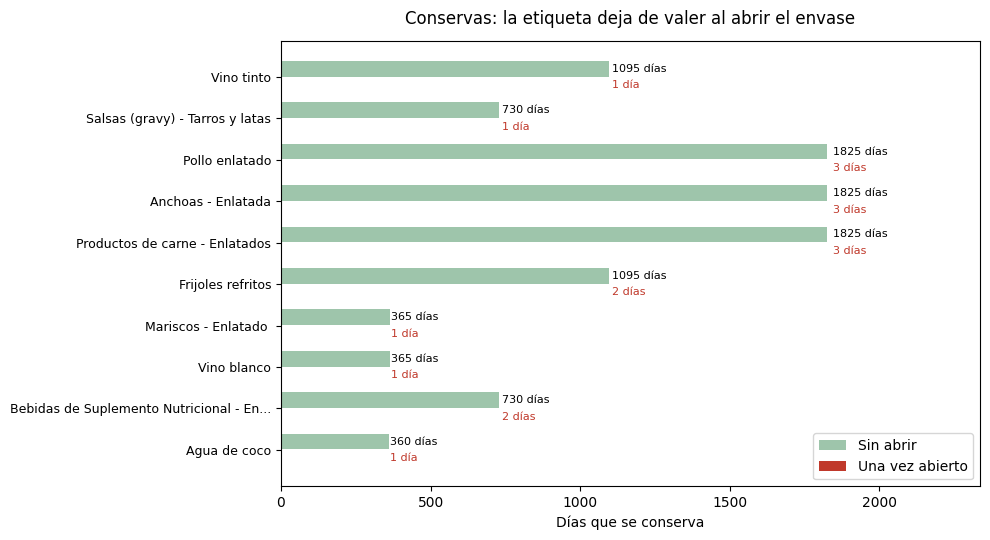

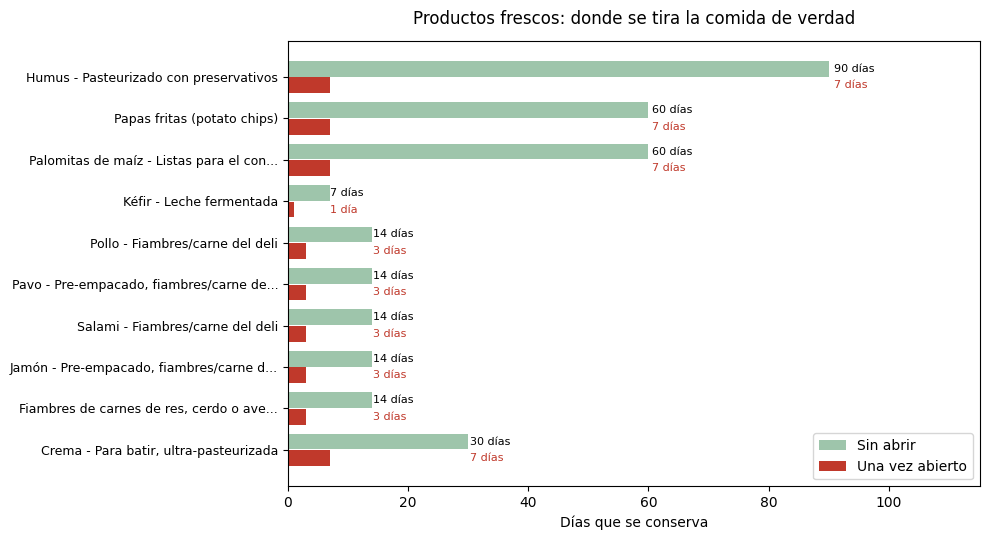

In [23]:
# 21. Gráficas comparativas en español
# Reutilizamos la función definida antes, ahora sobre nombres en español.
import numpy as np

def grafica_comparativa(tabla_datos, titulo):
    t = tabla_datos.sort_values('reduccion_x', ascending=False).head(10).sort_values('reduccion_x')
    y = np.arange(len(t))
    nombres = [n[:38] + '...' if len(n) > 38 else n for n in t.index]

    fig, ax = plt.subplots(figsize=(10, 5.5))
    ax.barh(y + 0.2, t['cerrado'], height=0.38, color='#9EC5AB', label='Sin abrir')
    ax.barh(y - 0.2, t['abierto'], height=0.38, color='#C0392B', label='Una vez abierto')

    for i, (c, a) in enumerate(zip(t['cerrado'], t['abierto'])):
        txt_c = f"{int(c)} día" if c == 1 else f"{int(c)} días"
        txt_a = f"{int(a)} día" if a == 1 else f"{int(a)} días"
        ax.text(c * 1.01, i + 0.2, txt_c, va='center', fontsize=8)
        ax.text(c * 1.01, i - 0.2, txt_a, va='center', fontsize=8, color='#C0392B')

    ax.set_yticks(y); ax.set_yticklabels(nombres, fontsize=9)
    ax.set_xlabel('Días que se conserva')
    ax.set_title(titulo, fontsize=12, pad=12)
    ax.set_xlim(0, t['cerrado'].max() * 1.28)
    ax.legend(loc='lower right')
    plt.tight_layout(); plt.show()

grafica_comparativa(tabla, 'Conservas: la etiqueta deja de valer al abrir el envase')
grafica_comparativa(tabla[tabla['cerrado'] <= 90],
                    'Productos frescos: donde se tira la comida de verdad')

In [24]:
# 22a. Traducir las categorías al español
# Las 25 categorías del FoodKeeper, para que las gráficas se lean en español.
CAT_ES = {
    'Produce - Fresh Fruits': 'Fruta fresca',
    'Produce - Fresh Vegetables': 'Verdura fresca',
    'Beverages': 'Bebidas',
    'Meat - Fresh': 'Carne fresca',
    'Meat - Smoked or Processed': 'Carne procesada',
    'Meat - Shelf Stable Foods': 'Carne no perecedera',
    'Meat - Stuffed or Assembled': 'Carne preparada',
    'Dairy Products & Eggs': 'Lácteos y huevos',
    'Condiments, Sauces & Canned Goods': 'Condimentos y conservas',
    'Deli & Prepared Foods': 'Platos preparados',
    'Shelf Stable Foods': 'Productos no perecederos',
    'Baked Goods - Baking and Cooking': 'Repostería y cocina',
    'Baked Goods - Bakery': 'Panadería',
    'Baked Goods - Refrigerated Dough': 'Masas refrigeradas',
    'Grains, Beans & Pasta': 'Cereales, legumbres y pasta',
    'Food Purchased Frozen': 'Congelados',
    'Poultry - Fresh': 'Pollo fresco',
    'Poultry - Cooked or Processed': 'Pollo cocinado',
    'Poultry - Shelf Stable Foods': 'Pollo no perecedero',
    'Poultry - Stuffed or Assembled': 'Pollo preparado',
    'Seafood - Fresh': 'Pescado fresco',
    'Seafood - Shellfish': 'Marisco',
    'Seafood - Smoked': 'Pescado ahumado',
    'Vegetarian Proteins': 'Proteínas vegetales',
    'Baby Food': 'Alimentación infantil',
}

datos['categoria_es'] = datos['Categoria'].map(CAT_ES).fillna(datos['Categoria'])
print("Categorías sin traducir:", datos['categoria_es'].isin(CAT_ES.keys()).sum())

Categorías sin traducir: 0


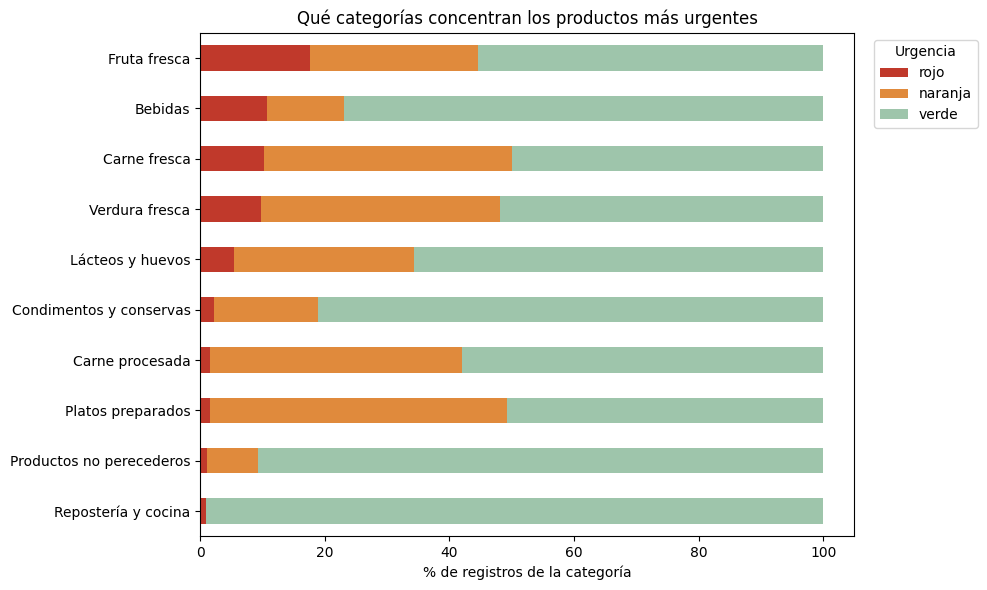

In [25]:
# 22. GRÁFICA 3: distribución de urgencia por categoría
# ¿Qué tipos de alimento concentran los casos urgentes?

# Top 10 categorías con más registros
top_cat = datos['categoria_es'].value_counts().head(10).index
sub = datos[datos['categoria_es'].isin(top_cat)]

# Porcentaje de cada urgencia dentro de cada categoría
tabla_urg = pd.crosstab(sub['categoria_es'], sub['urgencia'], normalize='index') * 100
tabla_urg = tabla_urg[['rojo', 'naranja', 'verde']]   # orden lógico
tabla_urg = tabla_urg.sort_values('rojo', ascending=True)

ax = tabla_urg.plot(kind='barh', stacked=True, figsize=(10, 6),
                    color=['#C0392B', '#E08A3C', '#9EC5AB'])
ax.set_xlabel('% de registros de la categoría')
ax.set_ylabel('')
ax.set_title('Qué categorías concentran los productos más urgentes')
ax.legend(title='Urgencia', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

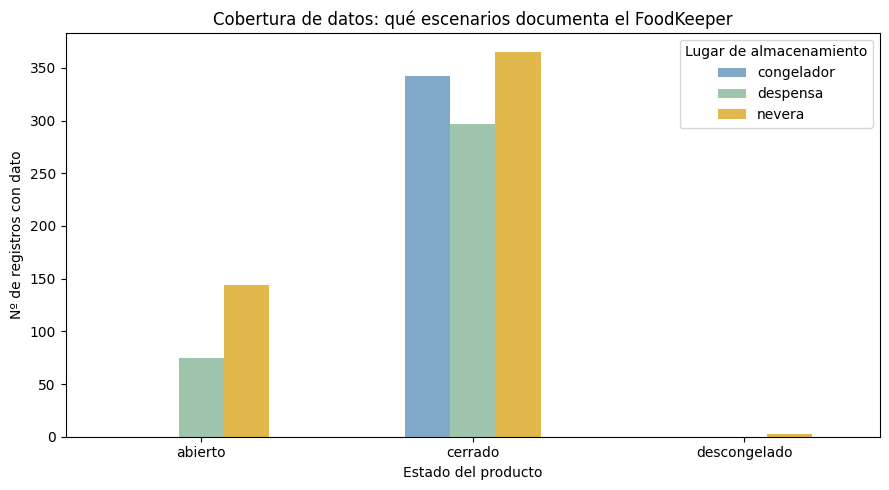

lugar         congelador  despensa  nevera
estado                                    
abierto                0        75     144
cerrado              342       297     365
descongelado           0         0       3


In [26]:
# 23. GRÁFICA 4: cobertura de datos por escenario
# Cuántos productos tienen información en cada combinación estado+lugar

cobertura = datos.groupby(['estado', 'lugar']).size().unstack(fill_value=0)

ax = cobertura.plot(kind='bar', figsize=(9, 5),
                    color=['#7FA8C9', '#9EC5AB', '#E0B84C'])
ax.set_xlabel('Estado del producto')
ax.set_ylabel('Nº de registros con dato')
ax.set_title('Cobertura de datos: qué escenarios documenta el FoodKeeper')
ax.legend(title='Lugar de almacenamiento')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(cobertura.to_string())

*Nota: los valores en cero corresponden a escenarios no aplicables (por ejemplo,
producto abierto en congelador), no a datos faltantes del USDA.*

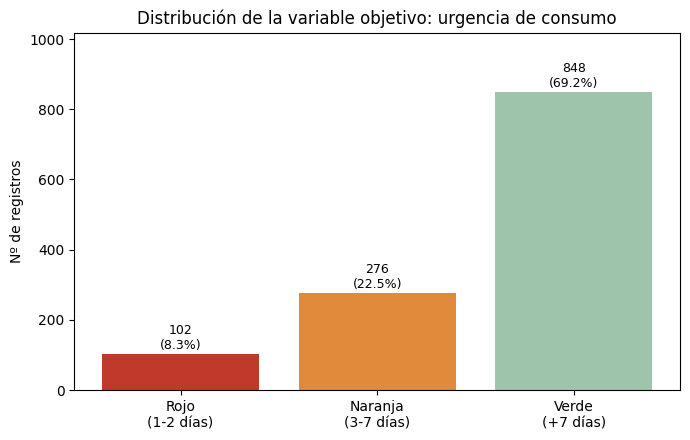

In [27]:
# 24. GRÁFICA 5: distribución de la variable objetivo
# Muestra el desbalance de clases, que habrá que tratar en el modelo
conteo_urg = datos['urgencia'].value_counts()[['rojo', 'naranja', 'verde']]

fig, ax = plt.subplots(figsize=(7, 4.5))
barras = ax.bar(['Rojo\n(1-2 días)', 'Naranja\n(3-7 días)', 'Verde\n(+7 días)'],
                conteo_urg.values, color=['#C0392B', '#E08A3C', '#9EC5AB'])

for barra, valor in zip(barras, conteo_urg.values):
    pct = valor / conteo_urg.sum() * 100
    ax.text(barra.get_x() + barra.get_width()/2, valor + 15,
            f"{valor}\n({pct:.1f}%)", ha='center', fontsize=9)

ax.set_ylabel('Nº de registros')
ax.set_title('Distribución de la variable objetivo: urgencia de consumo')
ax.set_ylim(0, conteo_urg.max() * 1.2)
plt.tight_layout()
plt.show()

In [28]:
# 25. Tabla final de features para el Módulo 1 (XGBoost)
# Variables predictoras: categoría, estado, lugar, referencia
# Variable objetivo: urgencia
# NOTA: dias_vida_util se guarda como referencia, pero no se usará como feature
features = datos[['nombre_es', 'categoria_es', 'estado', 'lugar',
                  'referencia', 'dias_vida_util', 'urgencia']].copy()

features.to_parquet(RUTA + 'features_modulo1.parquet')
features.to_csv(RUTA + 'features_modulo1.csv', index=False)

print("Guardado:", features.shape[0], "filas x", features.shape[1], "columnas")
print()
print(features.head(10).to_string())

Guardado: 1226 filas x 7 columnas

                                                                                                                    nombre_es         categoria_es   estado     lugar   referencia  dias_vida_util urgencia
0                                                                                                   Jerky/Carne seca - Casero  Carne no perecedera  cerrado  despensa  fabricacion            30.0    verde
1                                                        Tarta de fruta - Manzana,melocotón,arándano,albaricoque, cereza,mora            Panadería  cerrado  despensa  fabricacion             1.0     rojo
6                                                                                                              Azúcar - Negra  Repostería y cocina  cerrado  despensa  fabricacion          3650.0    verde
7                                                                                                          Azúcar - Granulada  Repostería y cocina  c

In [29]:
# 26. Preparar datos para el modelo
# Features: categoría, estado, lugar, referencia (variables categóricas)
# Target: urgencia (3 clases)

from sklearn.model_selection import train_test_split

X = pd.get_dummies(features[['categoria_es', 'estado', 'lugar', 'referencia']])
y = features['urgencia']

# Separamos train/test manteniendo la proporción de clases (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print("Variables predictoras tras dummies:", X.shape[1])
print("Entrenamiento:", X_train.shape[0], "| Test:", X_test.shape[0])
print()
print("Distribución en train:")
print(y_train.value_counts(normalize=True).round(3).to_string())

Variables predictoras tras dummies: 33
Entrenamiento: 919 | Test: 307

Distribución en train:
urgencia
verde      0.692
naranja    0.225
rojo       0.083


In [30]:
# 27. Comparación de modelos
# Baseline (siempre la clase mayoritaria) + Árbol + Random Forest + XGBoost
# Usamos F1-macro además de accuracy
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost necesita el target en números
le = LabelEncoder()
y_train_num = le.fit_transform(y_train)
y_test_num = le.transform(y_test)
print("Codificación de clases:", dict(zip(le.classes_, range(len(le.classes_)))))

modelos = {
    'Baseline (clase mayoritaria)': DummyClassifier(strategy='most_frequent'),
    'Árbol de decisión': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                             random_state=42, eval_metric='mlogloss'),
}

resultados = []
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train_num)
    pred = modelo.predict(X_test)
    resultados.append({
        'Modelo': nombre,
        'Accuracy': round(accuracy_score(y_test_num, pred), 3),
        'F1-macro': round(f1_score(y_test_num, pred, average='macro'), 3),
    })

comparativa = pd.DataFrame(resultados)
print()
print(comparativa.to_string(index=False))

Codificación de clases: {'naranja': 0, 'rojo': 1, 'verde': 2}

                      Modelo  Accuracy  F1-macro
Baseline (clase mayoritaria)     0.691     0.272
           Árbol de decisión     0.775     0.632
               Random Forest     0.811     0.675
                     XGBoost     0.818     0.699


              precision    recall  f1-score   support

     naranja       0.62      0.80      0.70        69
        rojo       0.55      0.46      0.50        26
       verde       0.94      0.87      0.90       212

    accuracy                           0.82       307
   macro avg       0.70      0.71      0.70       307
weighted avg       0.83      0.82      0.82       307



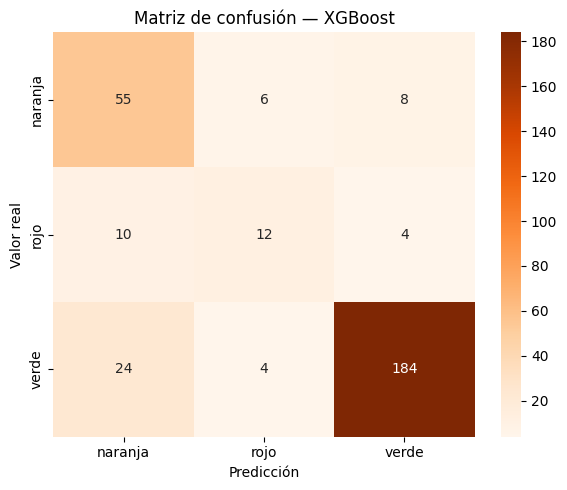

In [31]:
# 28. Modelo final y matriz de confusión
# XGBoost y  vemos dónde acierta y dónde falla por clase

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

modelo_final = modelos['XGBoost']
pred = modelo_final.predict(X_test)

print(classification_report(y_test_num, pred, target_names=le.classes_))

cm = confusion_matrix(y_test_num, pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor real')
ax.set_title('Matriz de confusión — XGBoost')
plt.tight_layout()
plt.show()

In [32]:
# 29. XGBoost con pesos de clase (mejorar detección de rojos)
# En seguridad alimentaria, no detectar un producto urgente (falso negativo) es más grave que una falsa alarma
from sklearn.utils.class_weight import compute_sample_weight

pesos = compute_sample_weight(class_weight='balanced', y=y_train_num)

modelo_pesado = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                              random_state=42, eval_metric='mlogloss')
modelo_pesado.fit(X_train, y_train_num, sample_weight=pesos)

pred_p = modelo_pesado.predict(X_test)
print(classification_report(y_test_num, pred_p, target_names=le.classes_))
print("F1-macro sin pesos:", round(f1_score(y_test_num, pred, average='macro'), 3))
print("F1-macro con pesos:", round(f1_score(y_test_num, pred_p, average='macro'), 3))

              precision    recall  f1-score   support

     naranja       0.58      0.86      0.69        69
        rojo       0.50      0.62      0.55        26
       verde       0.98      0.80      0.88       212

    accuracy                           0.80       307
   macro avg       0.69      0.76      0.71       307
weighted avg       0.85      0.80      0.81       307

F1-macro sin pesos: 0.699
F1-macro con pesos: 0.708


In [33]:
# 30. Interpretabilidad con SHAP

import shap

explainer = shap.TreeExplainer(modelo_pesado)
shap_values = explainer.shap_values(X_test)

print("Forma de los valores SHAP:", np.array(shap_values).shape)
print("Clases:", list(le.classes_))

Forma de los valores SHAP: (307, 33, 3)
Clases: ['naranja', 'rojo', 'verde']


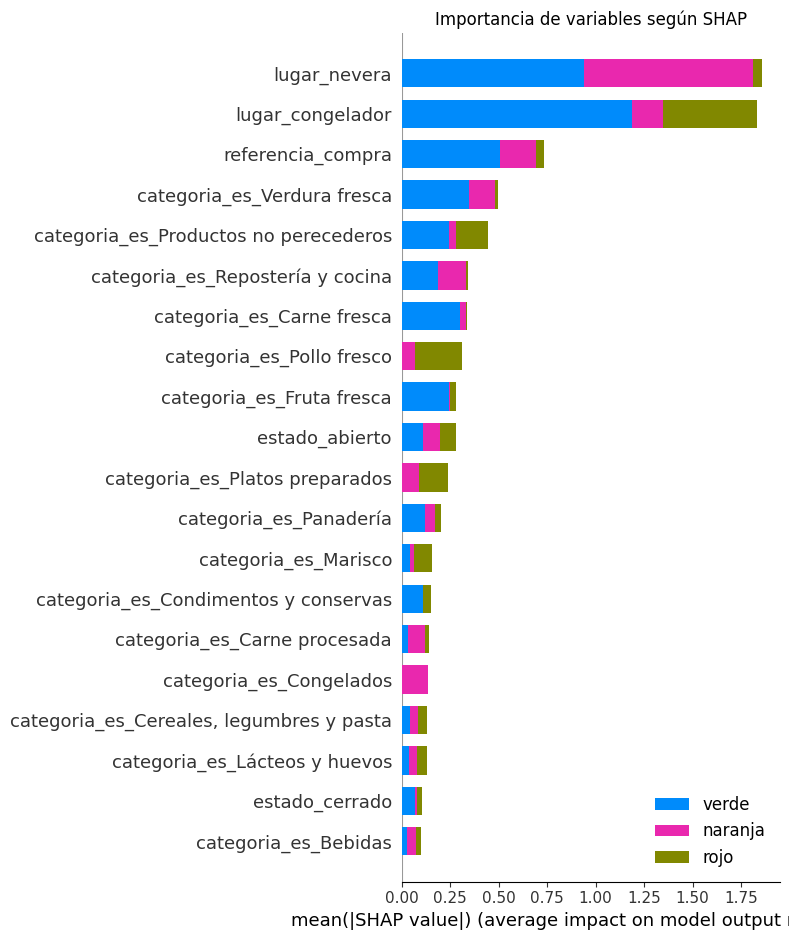

In [34]:
# 31. SHAP: importancia global de variables
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  class_names=list(le.classes_), show=False)
plt.title('Importancia de variables según SHAP')
plt.tight_layout()
plt.show()

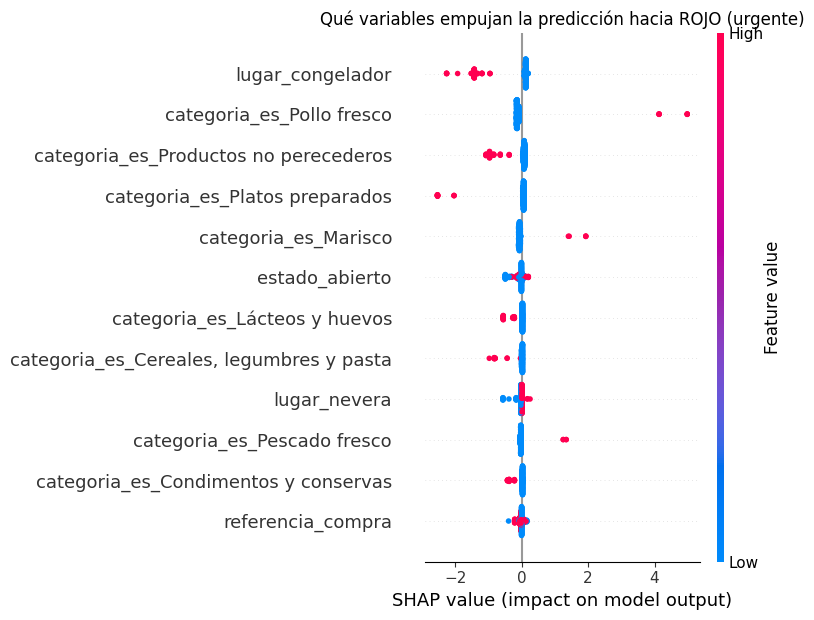

In [35]:
# 32. SHAP: qué empuja hacia la clase rojo
# Nos centramos en la clase crítica: ¿qué variables hacen que el modelo prediga urgencia máxima?

idx_rojo = list(le.classes_).index('rojo')

shap.summary_plot(shap_values[:, :, idx_rojo], X_test, show=False, max_display=12)
plt.title('Qué variables empujan la predicción hacia ROJO (urgente)')
plt.tight_layout()
plt.show()

## 5.1 Interpretabilidad con SHAP

Para entender qué hay detrás de cada predicción se aplicó SHAP (SHapley Additive
exPlanations), técnica que descompone la salida del modelo en la contribución
individual de cada variable.

El análisis muestra que el **lugar de almacenamiento** es el predictor dominante:
la nevera y el congelador concentran la mayor influencia media sobre las tres
clases. Le siguen el tipo de referencia temporal y las categorías de producto
fresco.

Al examinar específicamente la clase *rojo*, las variables que más empujan hacia
la máxima urgencia son las categorías de pollo fresco, marisco y pescado fresco,
mientras que el congelador actúa en sentido contrario, alejando la predicción de
la urgencia. Ambos comportamientos coinciden con el conocimiento del dominio, lo
que refuerza la validez del modelo.

El estado de apertura del envase presenta un efecto positivo sobre la urgencia,
aunque de magnitud moderada. Esta observación merece una lectura honesta: de las
1.226 observaciones del conjunto, solo 219 corresponden a productos abiertos, por
lo que el modelo dispone de menos evidencia para esa variable. El efecto existe y
apunta en la dirección esperada, pero su peso relativo está condicionado por la
cobertura del dataset original, donde el USDA documenta la vida útil tras apertura
únicamente para una parte de los productos.

In [36]:
# 33. Guardar el modelo y los objetos necesarios para la app
# Guardamos modelo, codificador de clases y nombres de columnas

import joblib

joblib.dump(modelo_pesado, RUTA + 'modelo_urgencia.pkl')
joblib.dump(le, RUTA + 'label_encoder.pkl')
joblib.dump(list(X.columns), RUTA + 'columnas_modelo.pkl')

# Guardamos también las listas de opciones para los desplegables de la app
opciones = {
    'categorias': sorted(features['categoria_es'].unique().tolist()),
    'estados': sorted(features['estado'].unique().tolist()),
    'lugares': sorted(features['lugar'].unique().tolist()),
    'referencias': sorted(features['referencia'].unique().tolist()),
}
joblib.dump(opciones, RUTA + 'opciones_app.pkl')

print("Guardados 4 ficheros en", RUTA)
print("Categorías disponibles:", len(opciones['categorias']))

Guardados 4 ficheros en /content/drive/MyDrive/TFM_FreshMind/
Categorías disponibles: 25


In [37]:
# --- 34. Generar el fichero app.py para Streamlit ---
# Página 1 de la app: añadir producto y ver su urgencia predicha.
# Asignatura: Productivizar modelos (Streamlit)

codigo = '''
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(page_title="FreshMind", page_icon="🥗", layout="wide")

@st.cache_resource
def cargar():
    modelo = joblib.load("modelo_urgencia.pkl")
    le = joblib.load("label_encoder.pkl")
    columnas = joblib.load("columnas_modelo.pkl")
    opciones = joblib.load("opciones_app.pkl")
    return modelo, le, columnas, opciones

modelo, le, columnas, opciones = cargar()

# Inventario en memoria de sesión
if "inventario" not in st.session_state:
    st.session_state.inventario = []

st.title("🥗 FreshMind")
st.caption("Predicción de urgencia real de consumo — TFM UCM 2026")

pagina = st.sidebar.radio("Navegación",
    ["Añadir producto", "Semáforo de urgencia", "Recetas sugeridas"])

if pagina == "Añadir producto":
    st.header("Añadir producto a tu despensa")
    col1, col2 = st.columns(2)
    with col1:
        nombre = st.text_input("Nombre del producto", "Yogur")
        categoria = st.selectbox("Categoría", opciones["categorias"])
    with col2:
        estado = st.selectbox("¿Está abierto?", opciones["estados"])
        lugar = st.selectbox("¿Dónde lo guardas?", opciones["lugares"])

    if st.button("Calcular urgencia", type="primary"):
        fila = pd.DataFrame([{"categoria_es": categoria, "estado": estado,
                              "lugar": lugar, "referencia": "compra"}])
        X = pd.get_dummies(fila).reindex(columns=columnas, fill_value=0)
        pred = le.inverse_transform(modelo.predict(X))[0]

        st.session_state.inventario.append(
            {"Producto": nombre, "Categoria": categoria,
             "Estado": estado, "Lugar": lugar, "Urgencia": pred})

        colores = {"rojo": "🔴 Consúmelo ya (1-2 días)",
                   "naranja": "🟠 Esta semana (3-7 días)",
                   "verde": "🟢 Tienes tiempo (+7 días)"}
        st.success(f"**{nombre}**: {colores[pred]}")
'''

with open('app.py', 'w') as f:
    f.write(codigo)

print("app.py generado. Descárgalo con la celda siguiente.")

app.py generado. Descárgalo con la celda siguiente.


In [38]:
from google.colab import files
files.download('app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
# 35. Completar app.py con las páginas 2 y 3
# Página 2: semáforo del inventario. Página 3: recetas priorizando urgentes
resto = '''

elif pagina == "Semáforo de urgencia":
    st.header("Tu despensa ahora mismo")
    if not st.session_state.inventario:
        st.info("Todavía no has añadido productos. Ve a 'Añadir producto'.")
    else:
        df = pd.DataFrame(st.session_state.inventario)
        orden = {"rojo": 0, "naranja": 1, "verde": 2}
        df = df.sort_values("Urgencia", key=lambda c: c.map(orden))

        c1, c2, c3 = st.columns(3)
        c1.metric("🔴 Urgentes", (df["Urgencia"] == "rojo").sum())
        c2.metric("🟠 Esta semana", (df["Urgencia"] == "naranja").sum())
        c3.metric("🟢 Con tiempo", (df["Urgencia"] == "verde").sum())

        st.dataframe(df, use_container_width=True)

        ahorro = (df["Urgencia"] != "verde").sum() * 2.5
        st.success(f"Consumiendo lo urgente evitas tirar unos {ahorro:.2f} € "
                   f"y unos {ahorro * 1.8:.1f} kg de CO2.")
        st.caption("Estimación basada en un coste medio de 2,5 €/producto "
                   "y 1,8 kg CO2 por euro de alimento desperdiciado.")

elif pagina == "Recetas sugeridas":
    st.header("Recetas con lo más urgente")
    if not st.session_state.inventario:
        st.info("Añade productos para recibir sugerencias.")
    else:
        df = pd.DataFrame(st.session_state.inventario)
        urgentes = df[df["Urgencia"].isin(["rojo", "naranja"])]
        if urgentes.empty:
            st.success("No tienes nada urgente. ¡Buen trabajo!")
        else:
            st.write("Prioriza estos ingredientes:")
            for _, fila in urgentes.iterrows():
                st.write(f"- **{fila['Producto']}** ({fila['Categoria']})")
            st.info("El motor semántico de recetas con Word2Vec sobre RecipeNLG "
                    "se describe en la memoria como línea de desarrollo.")
'''

with open('app.py', 'a') as f:
    f.write(resto)

# requirements.txt: versiones que necesita Streamlit Cloud
with open('requirements.txt', 'w') as f:
    f.write("streamlit\npandas\nscikit-learn\nxgboost\njoblib\n")

print("app.py completado y requirements.txt creado")

app.py completado y requirements.txt creado


In [40]:
from google.colab import files
files.download('app.py')
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>